#Feature Engineering

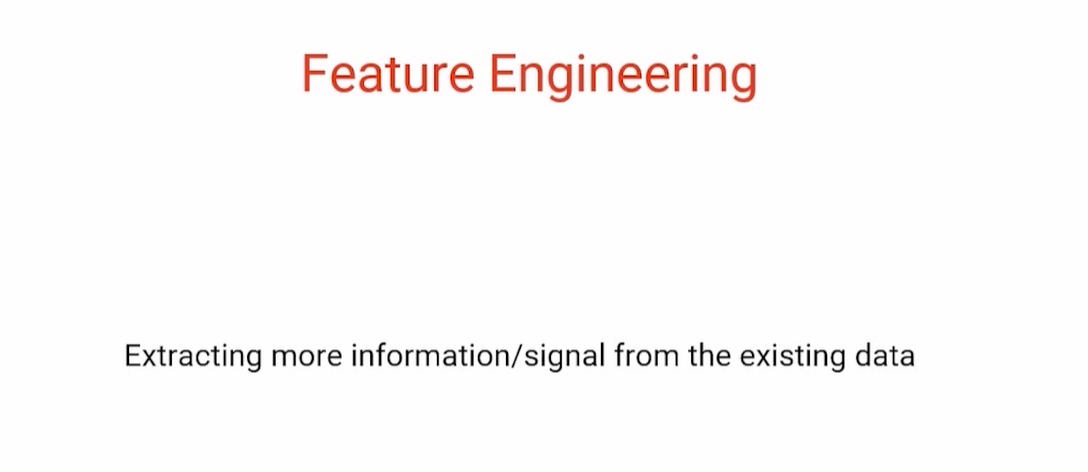

Feature engineering is transforming cleaned raw data into features/attributes that better represent the
underlying structure of your data and usually done with the help of domain experts.



In simple way we can say that transformation of cleaned raw data into features suitable for modeling.



We can divide Feature engineering steps as follows :



> Feature Extraction | Generation


> Feature selection



> feature Transformation

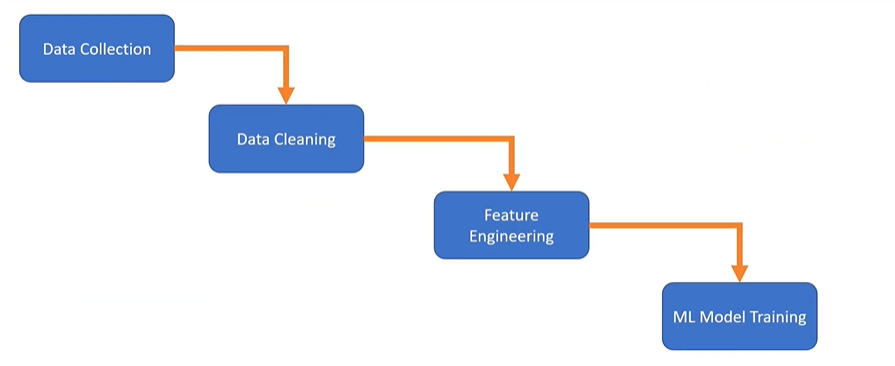

#1. Feature Extraction & Feature Generation

Feature extraction is usually used when the original raw data is very different and we cannot use raw
data for Machine Learning modeling then we transform raw data into the desired form.


Feature extraction is the method for creating a new and smaller set of features that captures most of
the useful information of raw data.



When we actually work in real world machine learning problem then we rarely get data in shape of CSV
so we have to extract the useful features from the raw data.


Some of the popular types of raw data from which features(new feature creation) can be extracted.
• Texts
> Images
• Geospatial data
• Date and time
> Sensors Data

##RAW DATA

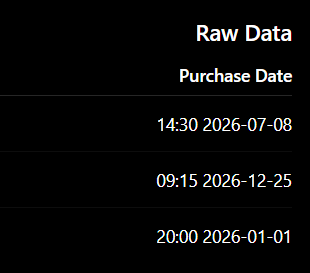

##Feature Extraction

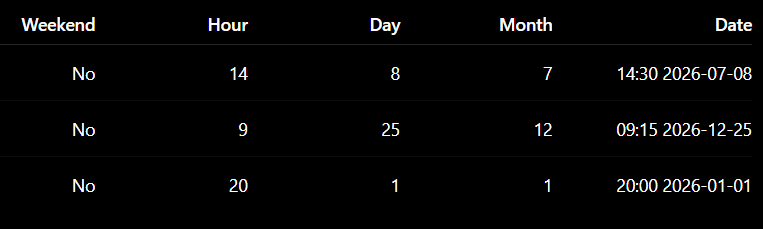

##RAW DATA

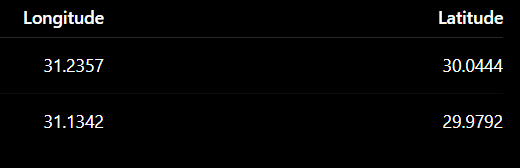

##Feature Extraction

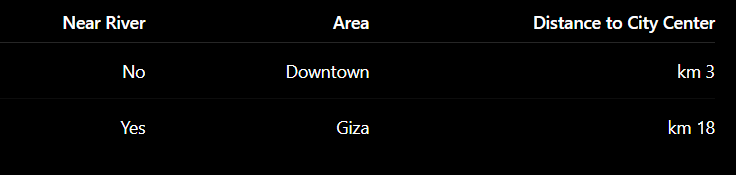

##RAW DATA

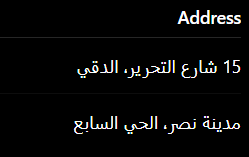

##Feature Extraction

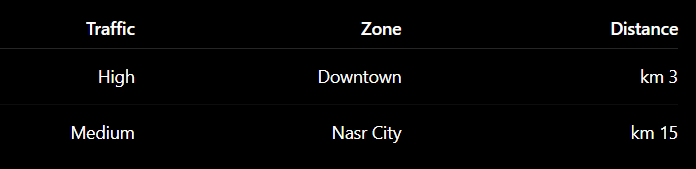

In [ ]:
import pandas as pd
df_titanic=pd.read_csv("/content/titanic.csv")

In [ ]:
df_Market=pd.read_csv("/content/Big Market.csv")

#Titanic

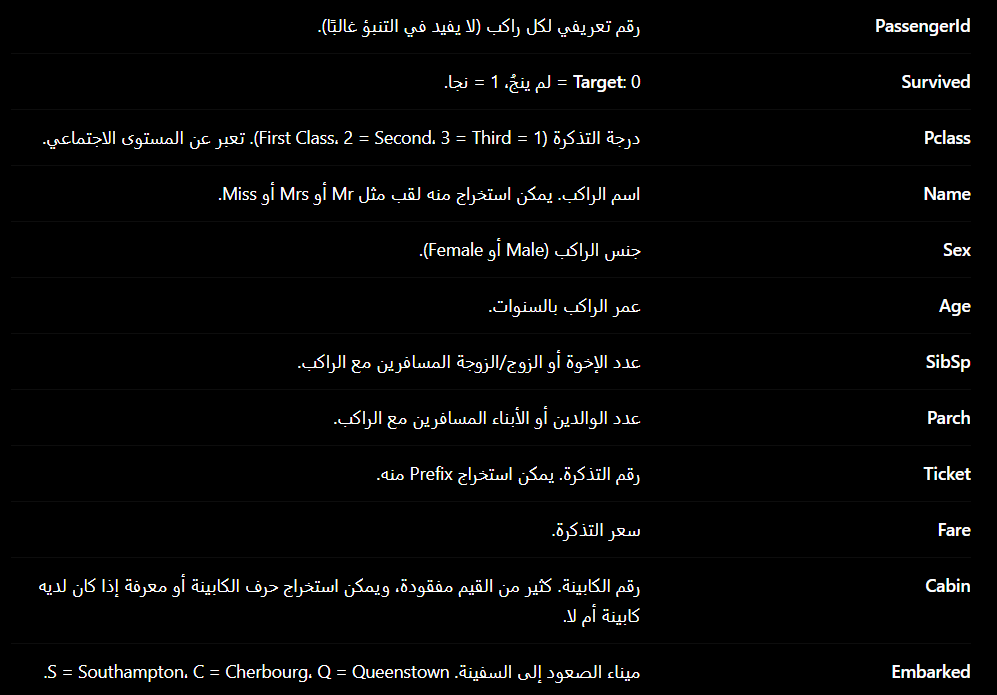

#New Features ?

In [ ]:
#family size
df_titanic["Family_Size"] = df_titanic["SibSp"] + df_titanic["Parch"] + 1

In [ ]:
#Is Alone
df_titanic["Is_Alone"] = (df_titanic["Family_Size"] == 1).astype(int)

In [ ]:
df_titanic["Name"].head(10)

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
5,"Moran, Mr. James"
6,"McCarthy, Mr. Timothy J"
7,"Palsson, Master. Gosta Leonard"
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)"
9,"Nasser, Mrs. Nicholas (Adele Achem)"


In [ ]:
#Title
df_titanic["Title"] = df_titanic["Name"].str.extract(r',\s*([^\.]+)\.')

In [ ]:
df_titanic["Title"]

,Title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rev
887,Miss
888,Miss
889,Mr


In [ ]:
#Age Grp
df_titanic["Age_Group"] = pd.cut(
    df_titanic["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

In [ ]:
#ticket price Category
df_titanic["Fare_Category"] = pd.cut(
    df_titanic["Fare"],
    bins=3,
    labels=["Low","Medium","High"]
)

#2 Market - Sales DataSet

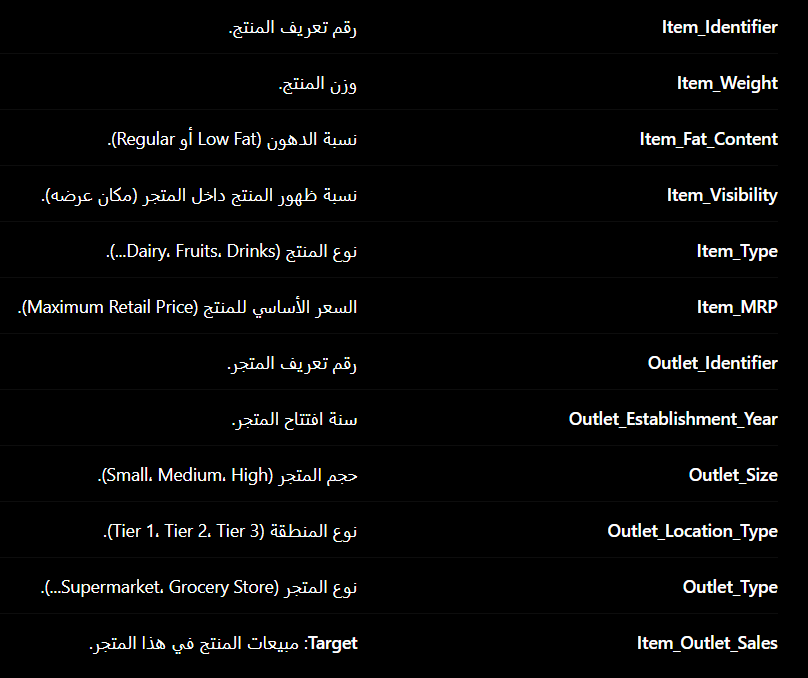

In [ ]:
df_Market.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,...,High_Price,Percent_HighPrice,Outlet_Min_MRP,Outlet_Max_MRP,Products_in_Outlet,Unique_ItemTypes,MRP_Diff,MRP_Ratio,MRP_Rank,MRP_Percentile
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,...,True,0.163441,32.4900,266.2884,930,16,109.511501,1.780565,882.0,0.947788
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,...,False,0.181034,31.8900,265.1884,928,16,-93.409434,0.340695,70.0,0.080371
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,...,False,0.163441,32.4900,266.2884,930,16,1.320301,1.009411,464.0,0.491904
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,...,False,0.153153,32.6558,266.6884,555,16,41.317406,1.293494,403.0,0.727561
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,...,False,0.177039,31.4900,266.6884,932,16,-87.564582,0.380845,96.5,0.104775


In [ ]:
#1- Store Age
#the Current year in the data is 2013
df_Market['storeAge']= 2013 - df_Market["Outlet_Establishment_Year"]

In [ ]:
#2-Item Category
#the first 2 char is the Cat
df_Market["Item_Category"] = df_Market["Item_Identifier"].str[:2]

In [ ]:
#convert Fd , DR , NC to readable names
df_Market["Item_Category"] = df_Market["Item_Category"].replace({
    "FD": "Food",
    "DR": "Drink",
    "NC": "Non-Consumable"
})

In [ ]:
#Price Category
df_Market["Price_Category"] = pd.cut(
    df_Market["Item_MRP"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [ ]:
#High Visibility
# if the item has visibility greater than the mean of the visibility of all the data =1 , 0
average_visibility = df_Market["Item_Visibility"].mean()

df_Market["High_Visibility"] = (
    df_Market["Item_Visibility"] > average_visibility
).astype(int)

In [ ]:
#Clean Low Fat Column
#Low Fat
#LF
#low fat
#Regular
#reg

In [ ]:
df_Market["Item_Fat_Content"] = df_Market["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

In [ ]:
df_Market["Low_Fat"] = (
    df_Market["Item_Fat_Content"] == "Low Fat"
).astype(int)

In [ ]:
df_Market.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,storeAge,Item_Category,Price_Category,High_Visibility,Low_Fat
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14,Food,High,0,1
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4,Drink,Low,0,0
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14,Food,Medium,0,1
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,15,Food,Medium,0,0
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26,Non-Consumable,Low,0,1


#Advanced Feature Generation

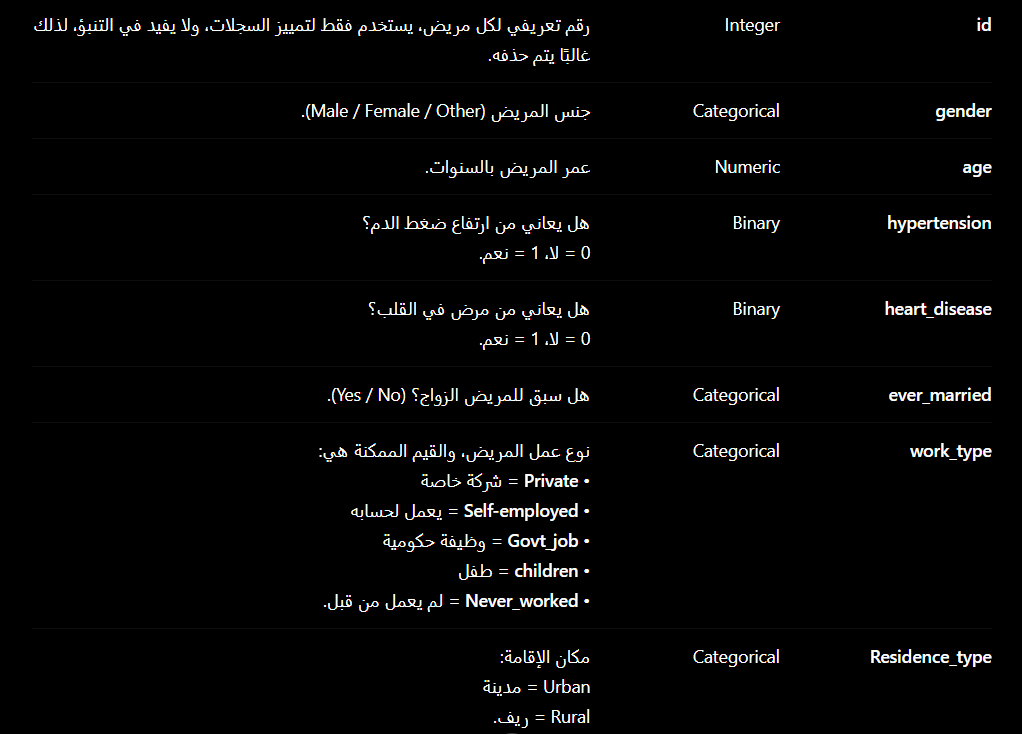

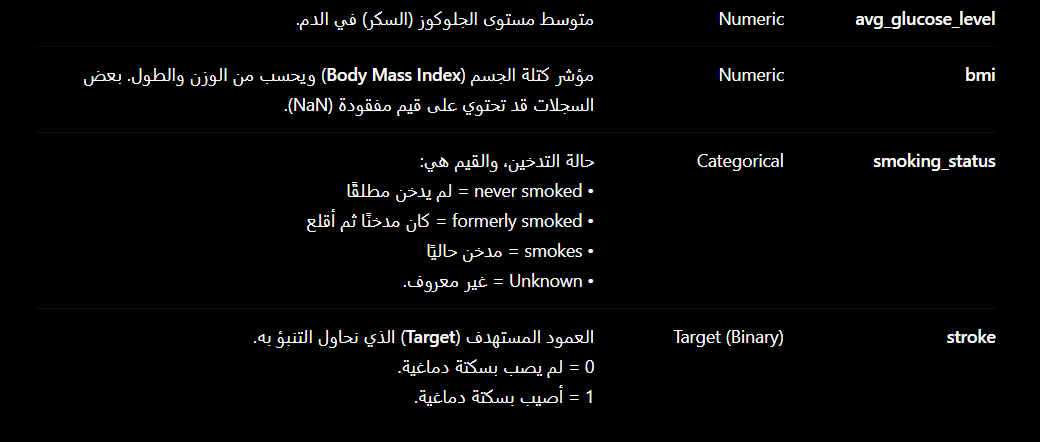

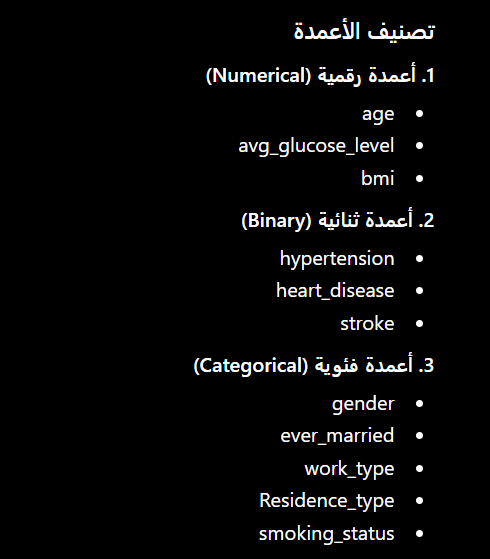

In [ ]:
df=pd.read_csv("/content/healthcare-dataset-stroke-data.csv")

In [ ]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


##Method 1
###Using Bins

In [ ]:
#Make Age Category
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[0,12,19,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

##Method 2
### Using Decision tree Split

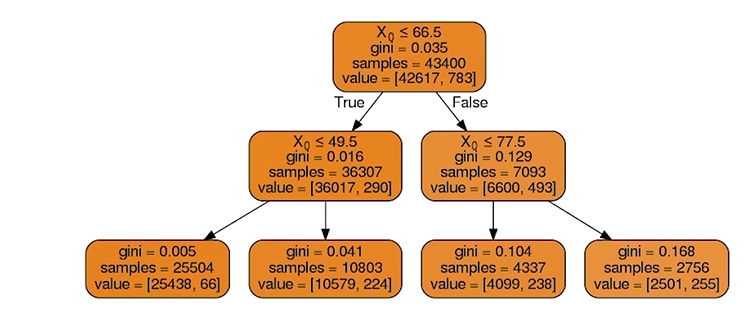

In [ ]:
from sklearn.tree import DecisionTreeClassifier

X = df[['age']]
y = df['stroke']

tree = DecisionTreeClassifier(
    max_leaf_nodes=4,
    random_state=42
)

tree.fit(X, y)

DecisionTreeClassifier(max_leaf_nodes=4, random_state=42)

In [ ]:
print(tree.tree_.threshold)

[67.5 53.5 75.5 -2.  -2.  -2.  -2. ]


In [ ]:
thresholds = tree.tree_.threshold

splits = []

for x in thresholds:
    if x != -2:
        splits.append(x)

splits.sort()

splits

[np.float64(53.5), np.float64(67.5), np.float64(75.5)]

In [ ]:
bins = [0] + splits + [100]

labels = [
    "Young",
    "Adult",
    "Senior",
    "Very Senior"
]

df["Age_Group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

In [ ]:
df[['age',"Age_Group"]]

,age,Age_Group
0,67.0,Adult
1,61.0,Adult
2,80.0,Very Senior
3,49.0,Young
4,79.0,Very Senior
...,...,...
5105,80.0,Very Senior
5106,81.0,Very Senior
5107,35.0,Young
5108,51.0,Young


In [ ]:
# BMI Category
df["BMI_Category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"],
    right=False
)

In [ ]:
# Glucose Category
df["Glucose_Category"] = pd.cut(
    df["avg_glucose_level"],
    bins=[0, 70, 140, float("inf")],
    labels=["Low", "Normal", "High"],
    right=False
)

In [ ]:
# Has Chronic Disease
df["Has_Chronic_Disease"] = (
    (df["hypertension"] == 1) |
    (df["heart_disease"] == 1)
).astype(int)

In [ ]:
df["Risk_Score"] = (
    (df["age"] >= 60).astype(int) +
    df["hypertension"] +
    df["heart_disease"] +
    df["smoking_status"].map({
        "never smoked": 0,
        "Unknown": 0,
        "formerly smoked": 1,
        "smokes": 2
    }).fillna(0)
)

In [ ]:
df["Risk_Score"]

,Risk_Score
0,3
1,1
2,2
3,2
4,2
...,...
5105,2
5106,1
5107,0
5108,1


In [ ]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,Age_Group,BMI_Category,Glucose_Category,Has_Chronic_Disease,Risk_Score
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Adult,Obese,High,1,3
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Adult,NaN,High,0,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Very Senior,Obese,Normal,1,2
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Young,Obese,High,0,2
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Very Senior,Normal,High,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0,Very Senior,NaN,Normal,1,2
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,Very Senior,Obese,Normal,0,1
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,Young,Obese,Normal,0,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0,Young,Overweight,High,0,1


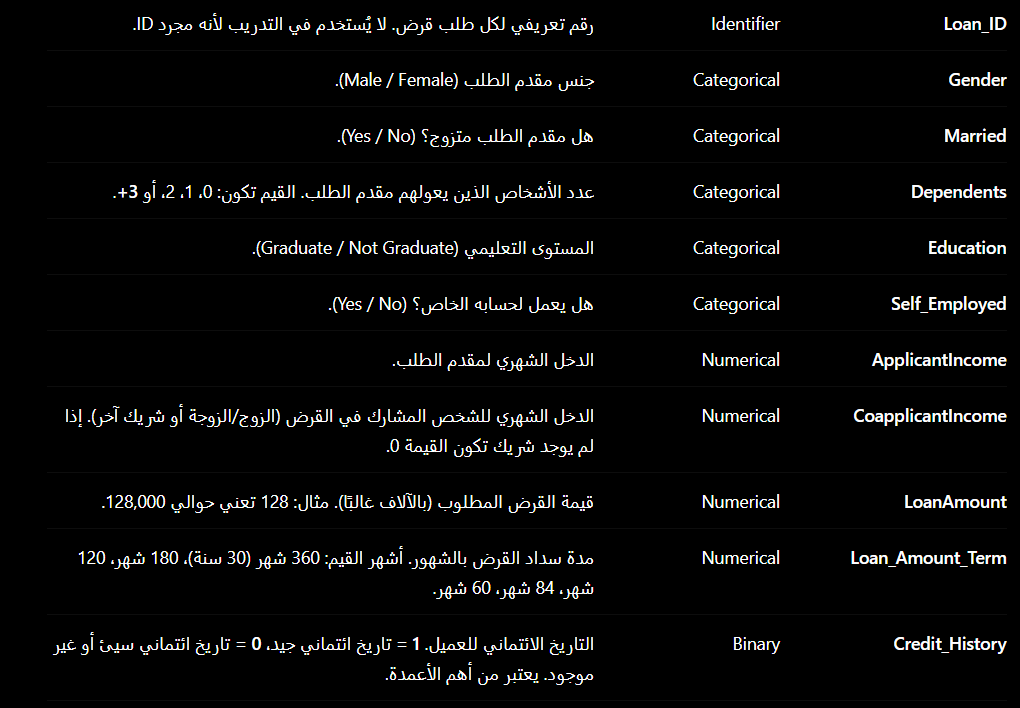

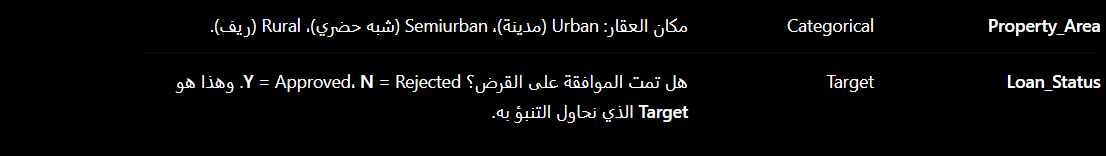

In [ ]:
df=pd.read_csv("/content/Loans.csv")

In [ ]:
#Total Income
df['Total Income']=df['applicantincome']+df['coapplicantincome']

In [ ]:
#Loans Amount And Income Ratio
df['Loan_income_ratio']=df['loanamount']/df['applicantincome']

In [ ]:
#Income Category
df["Income_Category"] = pd.cut(
    df["Total Income"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [ ]:
#Loan Category
df["Loan_Category"] = pd.cut(
    df["loanamount"],
    bins=3,
    labels=["Small", "Medium", "Large"]
)

In [ ]:
#EMI Estimate القسط الشهري للقرض
df["EMI"] = (
    df["loanamount"] /
    df["loan_amount_term"]
)

#feature Engineering with DateTime

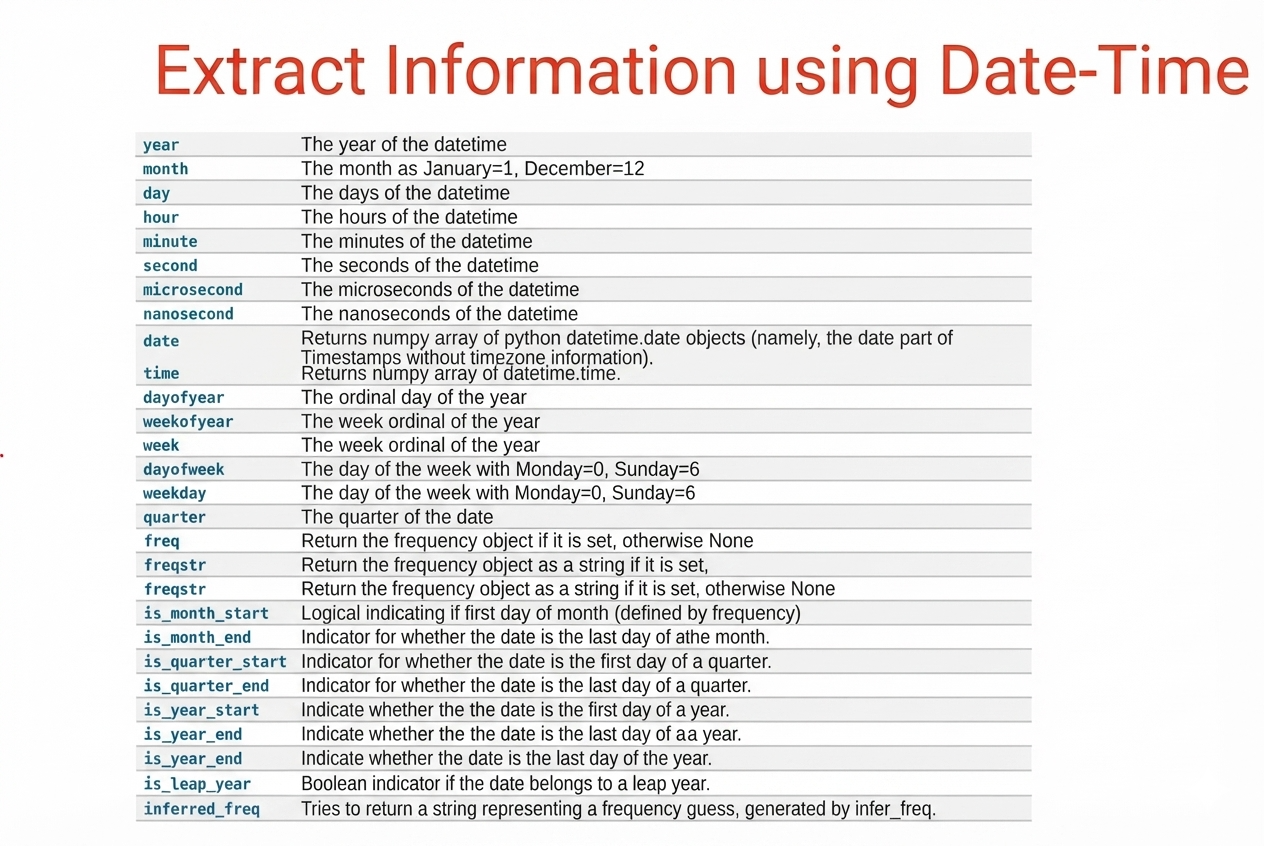

based on this data % No2 in the Air at specific day or time

In [ ]:
df=pd.read_excel("/content/AirQualityUCI.xlsx")

In [ ]:
df

,Date,Time,NOx(GT)
0,2004-03-10,18:00:00,166.0
1,2004-03-10,19:00:00,103.0
2,2004-03-10,20:00:00,131.0
3,2004-03-10,21:00:00,172.0
4,2004-03-10,22:00:00,131.0
...,...,...,...
9352,2005-04-04,10:00:00,471.7
9353,2005-04-04,11:00:00,353.3
9354,2005-04-04,12:00:00,293.0
9355,2005-04-04,13:00:00,234.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     9357 non-null   datetime64[ns]
 1   Time     9357 non-null   object        
 2   NOx(GT)  9357 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 219.4+ KB


In [ ]:
df['Date']=pd.to_datetime(df['Date'],format='%d/%m/%y')

In [ ]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

In [ ]:
#Year
df['Year'] = df['Date'].dt.year
df['Year']

,Year
0,2004
1,2004
2,2004
3,2004
4,2004
...,...
9352,2005
9353,2005
9354,2005
9355,2005


In [ ]:
#Month
df['Month'] = df['Date'].dt.month
df['Month']

,Month
0,3
1,3
2,3
3,3
4,3
...,...
9352,4
9353,4
9354,4
9355,4


In [ ]:
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Time'].dt.hour
df['MIN']=df['Time'].dt.minute
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Weekend'] = df['Date'].dt.dayofweek >= 5
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear


In [ ]:
df.head()

,Date,Time,NOx(GT),Year,Month,Day,Hour,DayOfWeek,Weekend,MIN,Quarter,DayOfYear
0,2004-03-10,1900-01-01 18:00:00,166.0,2004,3,10,18,Wednesday,False,0,1,70
1,2004-03-10,1900-01-01 19:00:00,103.0,2004,3,10,19,Wednesday,False,0,1,70
2,2004-03-10,1900-01-01 20:00:00,131.0,2004,3,10,20,Wednesday,False,0,1,70
3,2004-03-10,1900-01-01 21:00:00,172.0,2004,3,10,21,Wednesday,False,0,1,70
4,2004-03-10,1900-01-01 22:00:00,131.0,2004,3,10,22,Wednesday,False,0,1,70


#Automated Feature Engineering

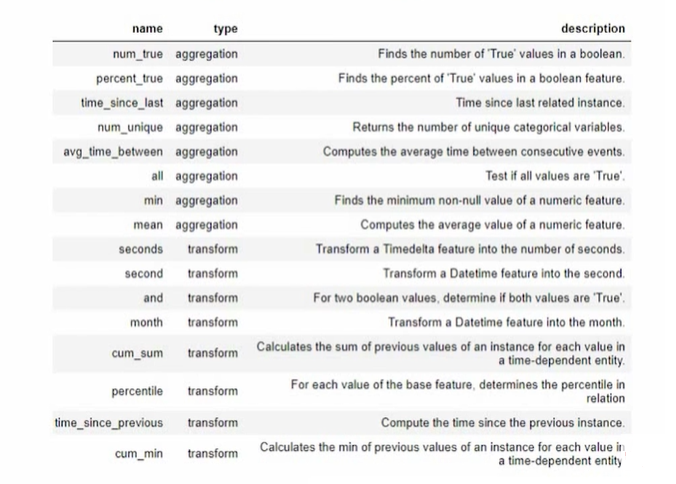

In [ ]:
!pip install featuretools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.9/587.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 15.0 MB/s eta 0:00:00


In [ ]:
import featuretools as ft

#Aggregation Features

In [ ]:
df_Market

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,storeAge,Item_Category,Price_Category,High_Visibility,Low_Fat
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14,Food,High,0,1
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4,Drink,Low,0,0
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14,Food,Medium,0,1
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,15,Food,Medium,0,0
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26,Non-Consumable,Low,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,26,Food,High,0,1
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850,11,Food,Low,0,0
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,9,Non-Consumable,Low,0,1
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,4,Food,Low,1,0


In [ ]:
df_Market["Outlet_Mean_MRP"] = (
    df_Market.groupby("Outlet_Identifier")["Item_MRP"]
      .transform("mean")
)

In [ ]:
df_Market["Outlet_Mean_MRP"]

,Outlet_Mean_MRP
0,140.297699
1,141.678634
2,140.297699
3,140.777594
4,141.425982
...,...
8518,141.425982
8519,140.950246
8520,143.122481
8521,141.678634


In [ ]:
#Highprice or not
df_Market["High_Price"] = df_Market["Item_MRP"] > 200
df_Market["Percent_HighPrice"] = (
    df_Market.groupby("Outlet_Identifier")["High_Price"]
      .transform("mean")*100
)

In [ ]:
df_Market["Percent_HighPrice"]

,Percent_HighPrice
0,16.344086
1,18.103448
2,16.344086
3,15.315315
4,17.703863
...,...
8518,17.703863
8519,17.222820
8520,16.881720
8521,18.103448


In [ ]:
# متوسط سعر المنتجات في كل متجر
df_Market["Outlet_Mean_MRP"] = df_Market.groupby("Outlet_Identifier")["Item_MRP"].transform("mean")

# أقل سعر
df_Market["Outlet_Min_MRP"] = df_Market.groupby("Outlet_Identifier")["Item_MRP"].transform("min")

# أعلى سعر
df_Market["Outlet_Max_MRP"] = df_Market.groupby("Outlet_Identifier")["Item_MRP"].transform("max")

# عدد المنتجات داخل المتجر
df_Market["Products_in_Outlet"] = df_Market.groupby("Outlet_Identifier")["Item_Identifier"].transform("count")

# عدد أنواع المنتجات
df_Market["Unique_ItemTypes"] = df_Market.groupby("Outlet_Identifier")["Item_Type"].transform("nunique")

# الفرق عن متوسط المتجر
df_Market["MRP_Diff"] = df_Market["Item_MRP"] - df_Market["Outlet_Mean_MRP"]

# نسبة السعر إلى متوسط المتجر
df_Market["MRP_Ratio"] = df_Market["Item_MRP"] / df_Market["Outlet_Mean_MRP"]

# ترتيب السعر داخل المتجر
df_Market["MRP_Rank"] = df_Market.groupby("Outlet_Identifier")["Item_MRP"].rank()

# ترتيب السعر كنسبة مئوية بين جميع المنتجات
df_Market["MRP_Percentile"] = df_Market["Item_MRP"].rank(pct=True)

In [ ]:
df_Market

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,...,High_Price,Percent_HighPrice,Outlet_Min_MRP,Outlet_Max_MRP,Products_in_Outlet,Unique_ItemTypes,MRP_Diff,MRP_Ratio,MRP_Rank,MRP_Percentile
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,...,True,0.163441,32.4900,266.2884,930,16,109.511501,1.780565,882.0,0.947788
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,...,False,0.181034,31.8900,265.1884,928,16,-93.409434,0.340695,70.0,0.080371
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,...,False,0.163441,32.4900,266.2884,930,16,1.320301,1.009411,464.0,0.491904
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,...,False,0.153153,32.6558,266.6884,555,16,41.317406,1.293494,403.0,0.727561
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,...,False,0.177039,31.4900,266.6884,932,16,-87.564582,0.380845,96.5,0.104775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,...,True,0.177039,31.4900,266.6884,932,16,73.095818,1.516849,789.0,0.853455
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,...,False,0.172228,33.1558,265.7884,929,16,-32.793246,0.767342,313.0,0.335504
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,...,False,0.168817,32.0558,266.5884,930,16,-58.000081,0.594752,172.0,0.202218
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,...,False,0.181034,31.8900,265.1884,928,16,-38.545434,0.727938,288.5,0.306641


#2- Feature Selection

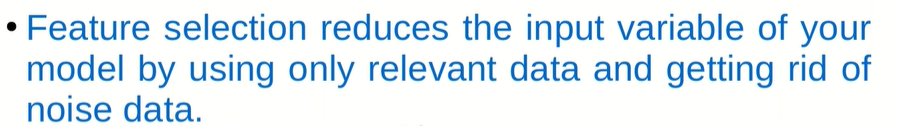

##Filter Methods

type of feature selection methods that work by selecting features based on some criteria prior to build the model

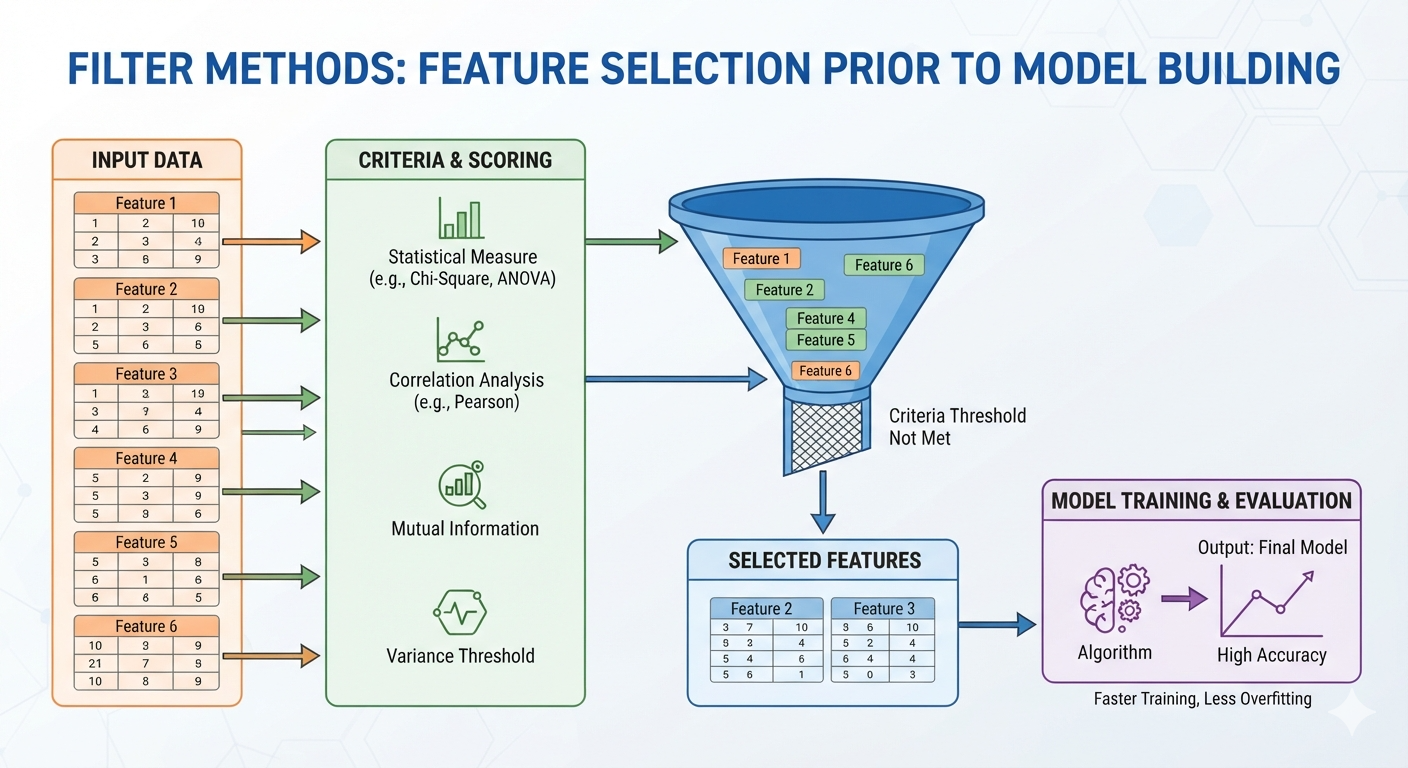

###1- Variance threshold

إذا كان عمود معين كل قيمه تقريبًا متشابهة، فهو غالبًا لن يساعد الموديل في التنبؤ.

Variance كبير → القيم مختلفة كثيرًا.


Variance صغير → القيم متقاربة.



Variance = 0 → جميع القيم متطابقة.



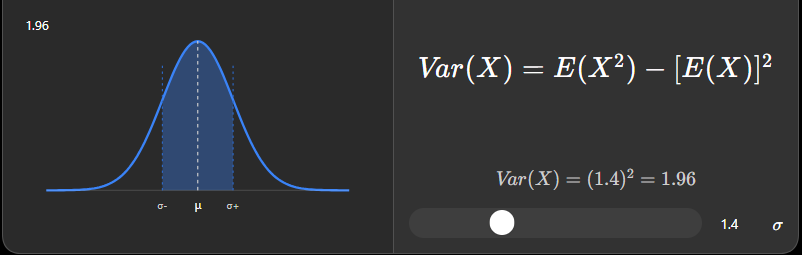

In [ ]:
df=pd.read_excel("/content/F_S.xlsx")

In [ ]:
df['married']=0

In [ ]:
df

,Age,Salary,City,Gender,buy,married
0,25,3000,0,0,1,0
1,45,9000,1,1,1,0
2,22,2500,0,0,0,0
3,55,12000,2,1,1,0
4,23,3500,0,0,1,0
5,42,9500,1,1,1,0
6,24,2400,0,0,0,0
7,54,13000,2,1,1,0
8,21,3000,0,0,1,0
9,44,9450,1,1,1,0


In [ ]:
x=df[['Age'	,'Salary',	'City',	'Gender','married']]
y=df['buy']

In [ ]:
x

,Age,Salary,City,Gender,married
0,25,3000,0,0,0
1,45,9000,1,1,0
2,22,2500,0,0,0
3,55,12000,2,1,0
4,23,3500,0,0,0
5,42,9500,1,1,0
6,24,2400,0,0,0
7,54,13000,2,1,0
8,21,3000,0,0,0
9,44,9450,1,1,0


In [ ]:
y

,buy
0,1
1,1
2,0
3,1
4,1
5,1
6,0
7,1
8,1
9,1


In [ ]:
from sklearn.feature_selection import VarianceThreshold

In [ ]:
selector=VarianceThreshold(threshold=0)

In [ ]:
selector.fit_transform(x)

array([[   25,  3000,     0,     0],
       [   45,  9000,     1,     1],
       [   22,  2500,     0,     0],
       [   55, 12000,     2,     1],
       [   23,  3500,     0,     0],
       [   42,  9500,     1,     1],
       [   24,  2400,     0,     0],
       [   54, 13000,     2,     1],
       [   21,  3000,     0,     0],
       [   44,  9450,     1,     1],
       [   20,  2350,     0,     0],
       [   53, 12000,     2,     1],
       [   26,  3000,     0,     0],
       [   41, 10500,     1,     1],
       [   27,  1900,     0,     0],
       [   56, 14000,     2,     1]])

In [ ]:
x.columns[selector.get_support()]

Index(['Age', 'Salary', 'City', 'Gender'], dtype='object')

##2-Correlation

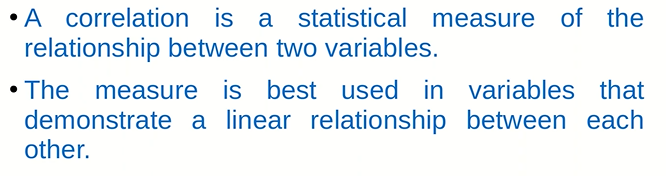

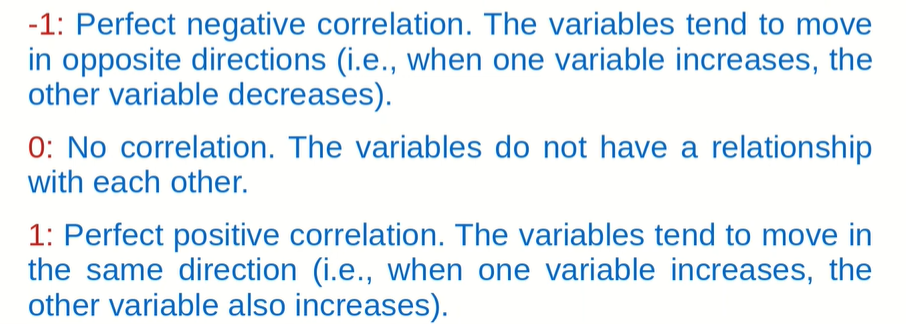

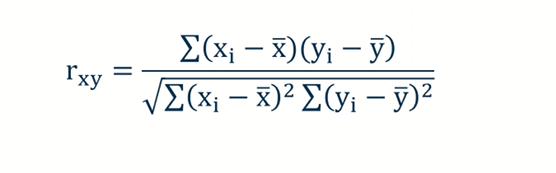

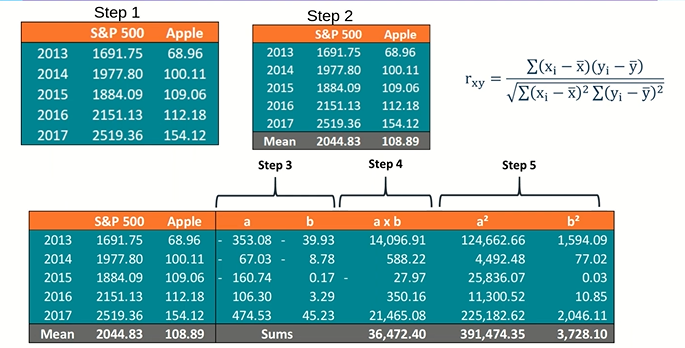

##Pearson's Correlation

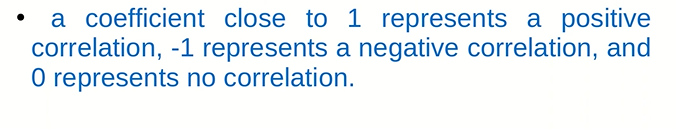

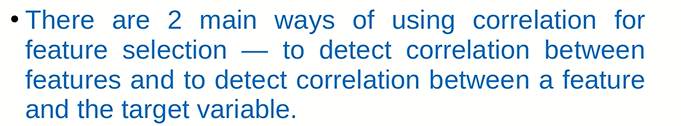

##1-Correlation between the features

corr between 2 features : high

then keeping just one feature to be used in the model

because the provide duplicate information

##2-Correlation between Features & target (Regression)



In [ ]:
df=pd.read_excel("/content/my_data.xlsx")

In [ ]:
df

,Home_NUM,Area,Bedrooms,Age_of_Home,Price
0,1,1850,3,12,345000
1,2,1200,2,25,215500
2,3,3200,4,5,610750
3,4,1500,3,18,280900
4,5,2100,3,10,395000
5,6,980,2,30,185000
6,7,2750,4,8,520300
7,8,1600,3,20,295600
8,9,2400,4,15,455000
9,10,1100,2,28,205400


In [ ]:
corr = df.corr(method='pearson')

corr["Price"].sort_values(ascending=False)

,Price
Price,1.000000
Area,0.998190
Bedrooms,0.949164
Home_NUM,0.154744
Age_of_Home,-0.934260


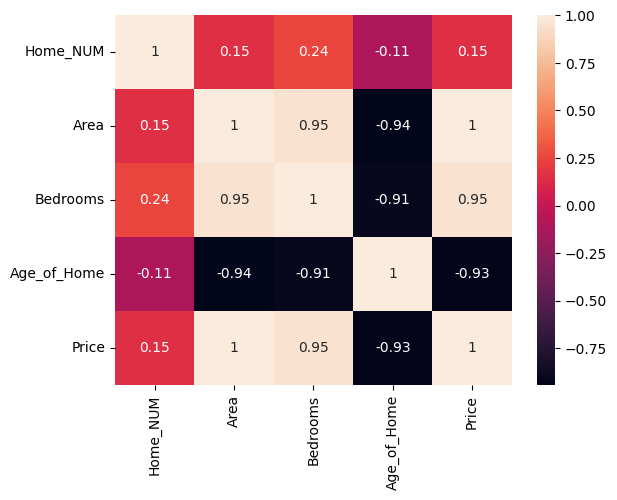

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(), annot=True)
plt.show()

#SelectKbest

1. feature selection method used in ML to slect top 'k' features based on statistical equ


2. selectkBest depend on scoring function




###Scoring Functions
For Classification
1. chi2 (Chi-Square Test)
2. f_classif (ANOVA F-value)
3. mutual_info_classif (Mutual Information)


For Regression



1. f_regression (ANOVA F-value for Regression)
2. mutual_info_regression (Mutual Information for Regression)



In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:
df=pd.read_csv("/content/students.csv",sep=";")

In [ ]:
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [ ]:
x.shape

(4424, 15)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


In [ ]:
selectKbest=SelectKBest(chi2,k=10)
x=selectKbest.fit_transform(X_scaled,y)
x.shape

(4424, 10)

In [ ]:
X.columns[selectKbest.get_support()].to_list()

['Application mode',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)']

#SelectPercentile

select the top 30% features


In [ ]:
from sklearn.feature_selection import SelectPercentile

selector = SelectPercentile(
    score_func=chi2,
    percentile=20
)

x=selector.fit_transform(X_scaled,y)
x.shape

(4424, 7)

In [ ]:
X.columns[selectKbest.get_support()].to_list()

['Application mode',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)']

#RFE : Recursive Feature Selection

train la el model , and use the model to select the features

Steps
1. train model on all features
2. delete the features has lowest important (Ex:city)
3. re-train the model without ( city)
4.  delete again


In [ ]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Read data
df = pd.read_csv("/content/students.csv", sep=";")

# Features & Target
X = df.drop("Target", axis=1)
y = df["Target"]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [ ]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
rfe=RFE(model,n_features_to_select=10)
x=rfe.fit_transform(X_train,y_train)
y_pred=rfe.predict(X_test)

In [ ]:
#to know the columns selected
selected_features = X_train.columns[rfe.get_support()]

print(selected_features.to_list())

['Course', 'Previous qualification (grade)', "Father's occupation", 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']


#RFECV : Recursive Feature Elimination with Cross Validation

Badel ma ba7ddd 10 features for example


basiib el model hwa eli ya3ref law7do kam features homa eli mohmiin

Steps :

1. 10 features - Accuracy
2. delete features - Accuracy


In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=50)

selector = RFECV(
    estimator=model,
    step=1,
    cv=3,
    scoring="accuracy"
)

X_selected = selector.fit_transform(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

#FFS = Forward Feature Selection

1. Selected = { }
2. try each feature individual
3. Selected = {add the best feature}
4. try per_feature + each Feature
5. add


In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=50)

ffs = SequentialFeatureSelector(
    model,
    k_features=5,
    forward=True,
    floating=False,
    scoring="accuracy",
    cv=5
)

ffs.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

['Tuition fees up to date', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
selected = list(ffs.k_feature_names_)
print(selected)

['Tuition fees up to date', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']


#BFS = Backward Feature Selection

1. Start with all features
2. try to delete feature
3. Accuracy
4. try to delete feature
5. Accuracy



In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=50)

bfs = SequentialFeatureSelector(
    model,
    k_features=3,
    forward=False,
    floating=False,
    scoring="accuracy",
    cv=2
)

bfs.fit(X, y)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/li

SequentialFeatureSelector(cv=2, estimator=LogisticRegression(max_iter=50),
                          forward=False, k_features=(3, 3), scoring='accuracy')

In [ ]:
selected = list(bfs.k_feature_names_)
print(selected)

['Tuition fees up to date', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']
